# Анализ химических характеристик вина и их влияния на качество

## Датасет
В данном проекте используется датасет о качестве вина (Wine Quality)  ([https://www.kaggle.com/datasets/shashankshekhar1205/wine-quality-dataset/data]). Датасет содержит физико-химические характеристики образцов красного вина. Данные были основаны на оценках как минимум трёх экспертов. Каждый эксперт оценивал качество вина по шкале от 0 до 10. Датасет включает 1599 образцов красного вина и несколько параметров:
- значения pH;
- содержание алкоголя;
- содержание лимонной кислоты;
- содержание сульфатов;
- содержание диоксидов серы;
- плотность;
- летучую кислотность;
- содержание сахара;
- качество вина.

#### Почему именно такой датасет?
Выбор датасета о качестве вина был обусловлен тем, что химический состав вина обладает биологической активностью, подтверждаемой актуальными научными исследованиями. Так, в одной статье ([https://sci-hub.ru/10.1002/mnfr.200500228]) показано, что мальвидин - один из антоцианинов, содержащихся в красном вине - влияет на процессы в клетках. Способность мальвидина задерживать клетки - это потенциально полезное свойство, так как оно позволяет мешать росту раковых клеток. Однако авторы подчёркивают, что механизм этого действия пока не до конца понятен, и в высоких концентрациях мальвидин может вызывать противоречивые эффекты. 

Цель проекта — исследовать, как химические параметры влияют на качество вина.

В этом проекте рассматриваются следующие вопросы:
1. Какие химические параметры сильнее всего влияют на качество вина?
2. Как содержание алкоголя связано с качеством вина?
3. Чем отличается летучая кислотность вин высокого и низкого качества?
4. Как связаны между собой плотность, содержание сахара и алкоголь?

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Импорт таблицы

In [69]:
wine = pd.read_csv("https://raw.githubusercontent.com/sofya-web/python/refs/heads/main/winequality-red.csv", sep=';')
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#### Анализ и очистка данных

In [70]:
wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [71]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [72]:
wine.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

## 1. Какие химические параметры сильнее всего влияют на качество вина?

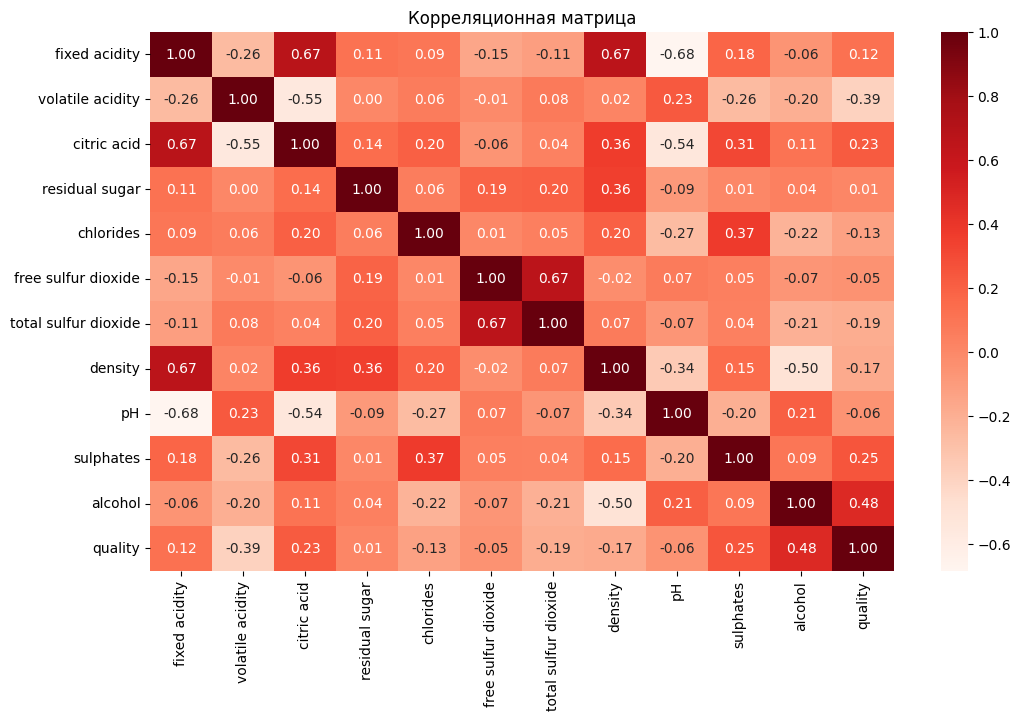

In [73]:
correlation_matrix = wine.corr()

plt.figure(figsize=(12, 7))

sns.heatmap(
    correlation_matrix,
    cmap='Reds',
    annot=True,
    fmt='.2f'
)

plt.title('Корреляционная матрица')
plt.show()

### Выводы
Корреляционная матрица показывает степень связи между параметрами. Я анализировала значения корреляции между химическими характеристиками и качеством вина (quality), так как был поставлен вопрос о влянии различных параметров на качество вина. Наиболее сильная положительная связь наблюдалась для содержания алкоголя, а наиболее сильная отрицательная — для летучей кислотности.

1. Корреляционная матрица показывает, что наиболее сильная положительная связь с качеством вина со занчением = 0.46 наблюдается у содержания алкоголя (alcohol). То есть, можно предположить, что при увеличении алкоголя качество продукта обычно тоже увеличивается. Это может свидетельствовать о том, что более качественные вина проходят более полный процесс брожения и обладают более выраженными вкусовыми характеристиками.

2. Наиболее заметная отрицательная корреляция (значение = -0.39) наблюдается между качеством вина и летучей кислотностью (volatile acidity). Повышенная кислотность может ухудшать вкус и аромат вина, что отрицательно влияет на качество конечного продукта.

3. Остальные параметры демонстрируют более слабые зависимости, из чего можно сделать вывод, что качество вина определяется совокупностью нескольких химических характеристик, а не одним отдельным фактором.

## 2. Как содержание алкоголя связано с качеством вина?

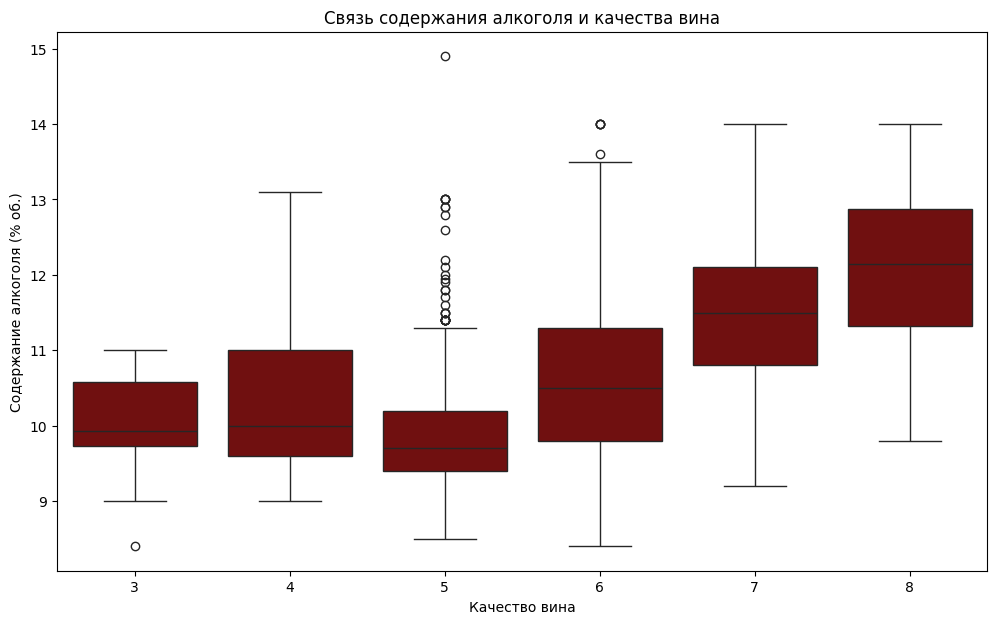

In [74]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    x='quality',
    y='alcohol',
    data=wine,
    color='maroon'
)

plt.title('Связь содержания алкоголя и качества вина')
plt.xlabel('Качество вина')
plt.ylabel('Содержание алкоголя (% об.)')
plt.show()

### Выводы
1. График показывает, что с увеличением качества вина возрастает и среднее содержание алкоголя. Так, для вина с оценкой качества = 7-8, содержания алкоголя в продукте значительно выше (11-13%), чем в винах, которые оцениваются на 3-6 балла.

2. По графику можно увидеть, что среднее значение блока выше у хороших вин. Для вин с более высокой оценкой характерны большие значения содержания спирта, тогда как менее качественные вина обычно содержат меньше алкоголя.

3. Полученные результаты позволяют предположить, что содержание алкоголя является одним из важных факторов, влияющих на восприятие качества вина экспертами. Этот вывод можно сделать из взаимосвязь алкоголь-качество, повторяющейся на всём графике.

## 3. Чем отличается летучая кислотность вин высокого и низкого качества?

In [75]:
high_quality = wine[wine['quality'] >= 7]
low_quality = wine[wine['quality'] <= 5]

print(
    'Средняя кислотность у вин высокого качества:',
    high_quality['volatile acidity'].mean()
)

print(
    'Средняя кислотность у вин низкого качества:',
    low_quality['volatile acidity'].mean()
)

Средняя кислотность у вин высокого качества: 0.4055299539170507
Средняя кислотность у вин низкого качества: 0.589502688172043


### Построим график, где сравнивается зависимость летучей кислотности от качества вина

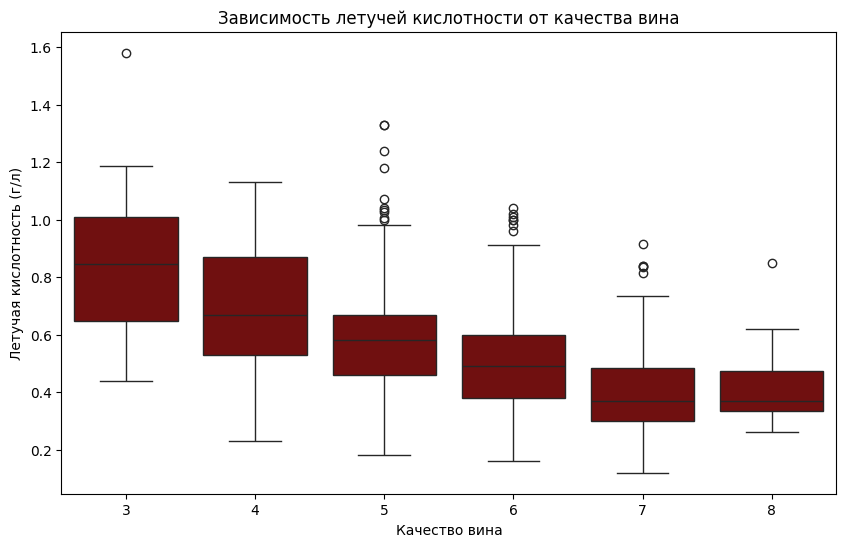

In [76]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='quality',
    y='volatile acidity',
    data=wine,
    color='maroon'
)

plt.title('Зависимость летучей кислотности от качества вина')
plt.xlabel('Качество вина')
plt.ylabel('Летучая кислотность (г/л)')
plt.show()

### Выводы
Летучая кислотность - это показатель содержания в вине органических кислот, которые испаряются при нагревании и придают напитку резкий аромат. Основная из них является уксусная кислота. В минимальных количествах она есть в любом вине, но при превышении нормы ухудшает качество напитка. 

1. Полученные средние значения позволяют количественно сравнить группы вин высокого и низкого качества. Они показывает, что у менее качественных вин средняя летучая кислотность значительно выше.  Повышенная летучая кислотность может быть связана с накоплением уксусной кислоты и побочных продуктов брожения, ухудшающих вкус и аромат вина.

2. График также показывает, что с повышением качества вина уменьшается как показатель летучей кислотности, так и разброс полученных результатов.
Такое распределение может быть связано с технологией производства конечного продукта.

3. Полученные данные могут свидетельствовать о том, что повышенная кислотность ухудшает органолептические свойства вина, включая вкус и аромат, тем самым снижает качество целового продукта. Так как у вин высокого качества (7-8) показатель летучей кислотности = 0.4 г/л, в то время как для низкокачественных вин (3-6) он равен больше 0.5 г/л

## 4. Как связаны между собой плотность, содержание сахара и алкоголь?

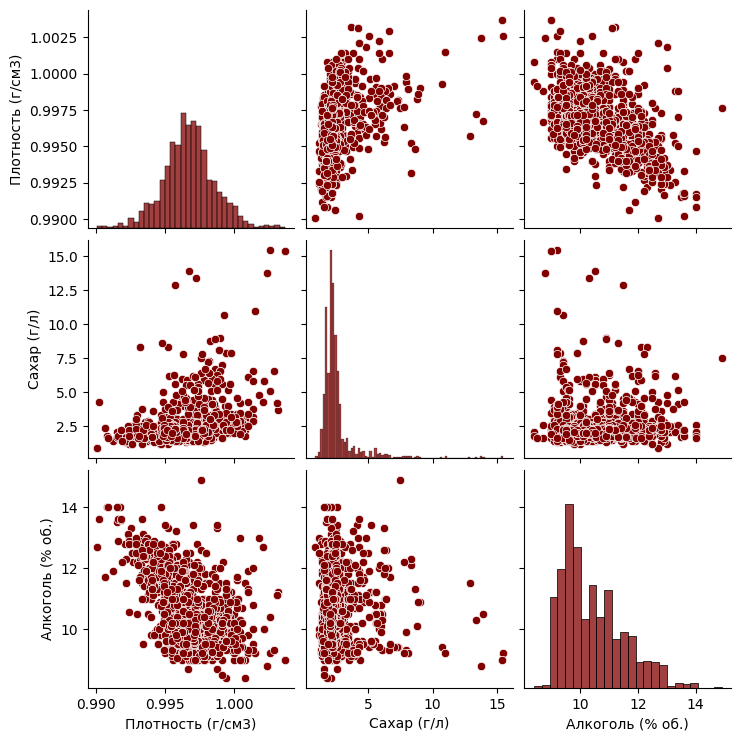

In [77]:
selected_columns.columns = [
    'Плотность (г/см3)',
    'Сахар (г/л)',
    'Алкоголь (% об.)'
]

sns.pairplot(
    selected_columns,
    plot_kws={'color': 'maroon'},
    diag_kws={'color': 'maroon'}
)

plt.show()

### Выводы
1. Анализ взаимосвязей показывает, что при увеличении содержания сахара плотность вина возрастает. Это объясняется тем, что растворённые сахара увеличивают массу раствора.

2. Между содержанием алкоголя и плотностью наблюдается обратная зависимость: при увеличении концентрации спирта плотность уменьшается. Это объясняется свойствами этанола, плотность которого ниже плотности воды.

3. Полученные зависимости демонстрируют, что химические параметры вина тесно связаны между собой и отражают особенности состава и процессов брожения. Так как во время брожения сахар превращается в спирт: C6​H12​O6​ = 2C2​H5​OH + 2CO2​, то при большом количесве переработки сахара образуется больше спирта, а плотность продукта, как было написано выше, зависит от обоих факторов.

# Общие выводы

1. В ходе выполнения проекта был проведён анализ датасета о химических характеристиках красного вина и их влиянии на оценку качества.

2. Было установлено, что:
- наиболее сильное положительное влияние на оценку качества оказывает содержание алкоголя (коэффициент корреляции = 0.46), а наиболее сильное отрицательное - летучая кислотность (коэффициент = -0.39). Остальные параметры демонстрируют более слабую связь, что свидетельствует о комплексной природе восприятия качества;
- вина с более высокой оценкой (7-8) систематически содержат больше алкоголя (в среднем 11-13%), чем вина низкого качества (3-4). Это позволяет предположить, что алкоголь является значимым предиктором экспертной оценки;
- для вин высокого качества (7-8) средняя летучая кислотность составила = 0.4, для вин низкого качества (3-6) = 0.59. График подтвердил, что у низкокачественных вин кислотность не только выше, но и более вариативна;
- анализ взаимосвязей между плотностью, содержанием сахара и алкоголем показал существование закономерностей, соответствующих физико-химическим свойствам растворов: 
    - положительная связь между содержанием сахара и плотностью (сахар увеличивает плотность раствора);
    - отрицательная связь между содержанием алкоголя и плотностью (этанол имеет меньшую плотность, чем вода).

3. Для анализа данных были использованы библиотеки pandas, matplotlib и seaborn.

Результаты работы показывают, что качество красного вина в значительной степени определяется двумя ключевыми параметрами: содержанием алкоголя и летучей кислотностью. Влияние остальные характеристик может проявляться лишь в комбинации с другими факторами. Полученные выводы согласуются как с технологическими представлениями о производстве вина, так и с данными научных исследований о роли органических кислот и спиртов в органолептике.